# AnyLoc thesis figures

This notebook reproduces the standard retrieval analyses and adds DINOv2 local-feature and VLAD cluster visualisations for the AnyLoc run in `outputs/_anyloc_similarity.csv`.

In [8]:
from __future__ import annotations
import csv, importlib, sys
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from PIL import Image

PROJECT_ROOT=Path.cwd().resolve()
if PROJECT_ROOT.name=='notebooks': PROJECT_ROOT=PROJECT_ROOT.parent
sys.path.insert(0,str(PROJECT_ROOT/'src'))
FIGURE_DIR=PROJECT_ROOT/'outputs/thesis_figures/anyloc'; FIGURE_DIR.mkdir(parents=True,exist_ok=True)
DATABASE_DIR=PROJECT_ROOT/'datasets/dataset-2/frames-IMG_3609'; QUERY_DIR=PROJECT_ROOT/'datasets/dataset-2/frames-IMG_3610'
DATABASE_LABELS_CSV=PROJECT_ROOT/'datasets/dataset-2/labels/frames-IMG_3609.csv'; QUERY_LABELS_CSV=PROJECT_ROOT/'datasets/dataset-2/labels/frames-IMG_3610.csv'
SIMILARITY_CSV=PROJECT_ROOT/'outputs/_anyloc_similarity.csv'; TOP_K_VALUES=[1,5,10,20]
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,'figure.dpi':130})

## Evaluate AnyLoc and select qualitative examples

In [ ]:
def labels(path):
    with path.open(newline='',encoding='utf-8') as handle: return {Path(row['image_path']).name:row['label'].strip().casefold() for row in csv.DictReader(handle)}
def top(scores,k):
    candidates=np.argpartition(scores,-k)[-k:]; return candidates[np.argsort(-scores[candidates])]
database_paths=sorted(DATABASE_DIR.glob('*.jpg')); query_paths=sorted(QUERY_DIR.glob('*.jpg')); query_by_name={path.name:path for path in query_paths}
database_label_by_name,query_label_by_name=labels(DATABASE_LABELS_CSV),labels(QUERY_LABELS_CSV); database_labels=np.asarray([database_label_by_name[path.name] for path in database_paths],dtype=object)
if not SIMILARITY_CSV.is_file(): raise FileNotFoundError(f'AnyLoc CSV not found: {SIMILARITY_CSV}')
totals={k:0 for k in TOP_K_VALUES}; count_by_label=Counter(); correct_by_label=Counter(); confusions=Counter(); examples=[]; evaluated=0
with SIMILARITY_CSV.open(newline='',encoding='utf-8') as handle:
    reader=csv.reader(handle); header=next(reader)
    if len(header)-2!=len(database_paths): raise ValueError('The AnyLoc CSV does not match the current database ordering.')
    for row in reader:
        query_path=query_by_name.get(Path(row[1]).name)
        if query_path is None: raise FileNotFoundError(f'Query image from CSV is missing: {row[1]}')
        true_label=query_label_by_name.get(query_path.name)
        if true_label is None: continue
        scores=np.asarray(row[2:],dtype=np.float32); ranks=top(np.nan_to_num(scores,nan=-np.inf),max(TOP_K_VALUES)); top5=ranks[:5]; predicted_label=str(database_labels[int(ranks[0])]); is_correct=predicted_label==true_label
        evaluated+=1; count_by_label[true_label]+=1; correct_by_label[true_label]+=is_correct; confusions[(true_label,predicted_label)]+=1
        for k in TOP_K_VALUES: totals[k]+=bool(np.any(database_labels[ranks[:k]]==true_label))
        examples.append({'query_index':int(row[0]),'query_path':query_path,'query_label':true_label,'top5_indices':top5,'top5_scores':scores[top5],'top5_correct':database_labels[top5]==true_label})
recall={k:totals[k]/evaluated for k in TOP_K_VALUES}; print(f'Evaluated {evaluated:,} queries. AnyLoc Recall@1: {recall[1]:.1%}')
all_correct=[row for row in examples if row['top5_correct'].all()]; one_incorrect=[row for row in examples if row['top5_correct'].sum()==4]
if len(all_correct)<2 or not one_incorrect: raise RuntimeError('Could not find the requested top-5 example mix.')


Evaluated 4,284 queries. AnyLoc Recall@1: 81.1%


## 1. Recall@K, label outcomes, confusion matrix, and top-5 retrievals

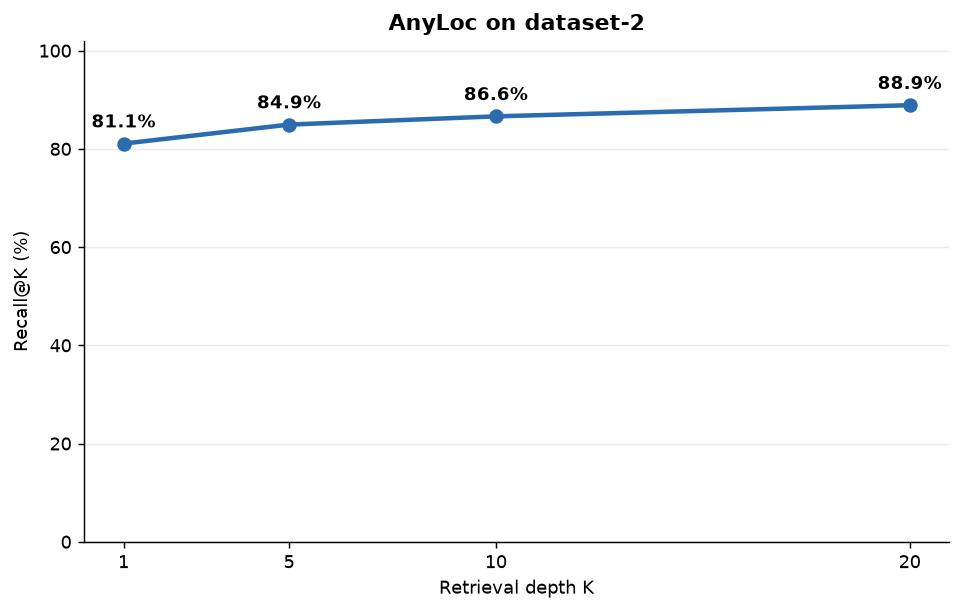

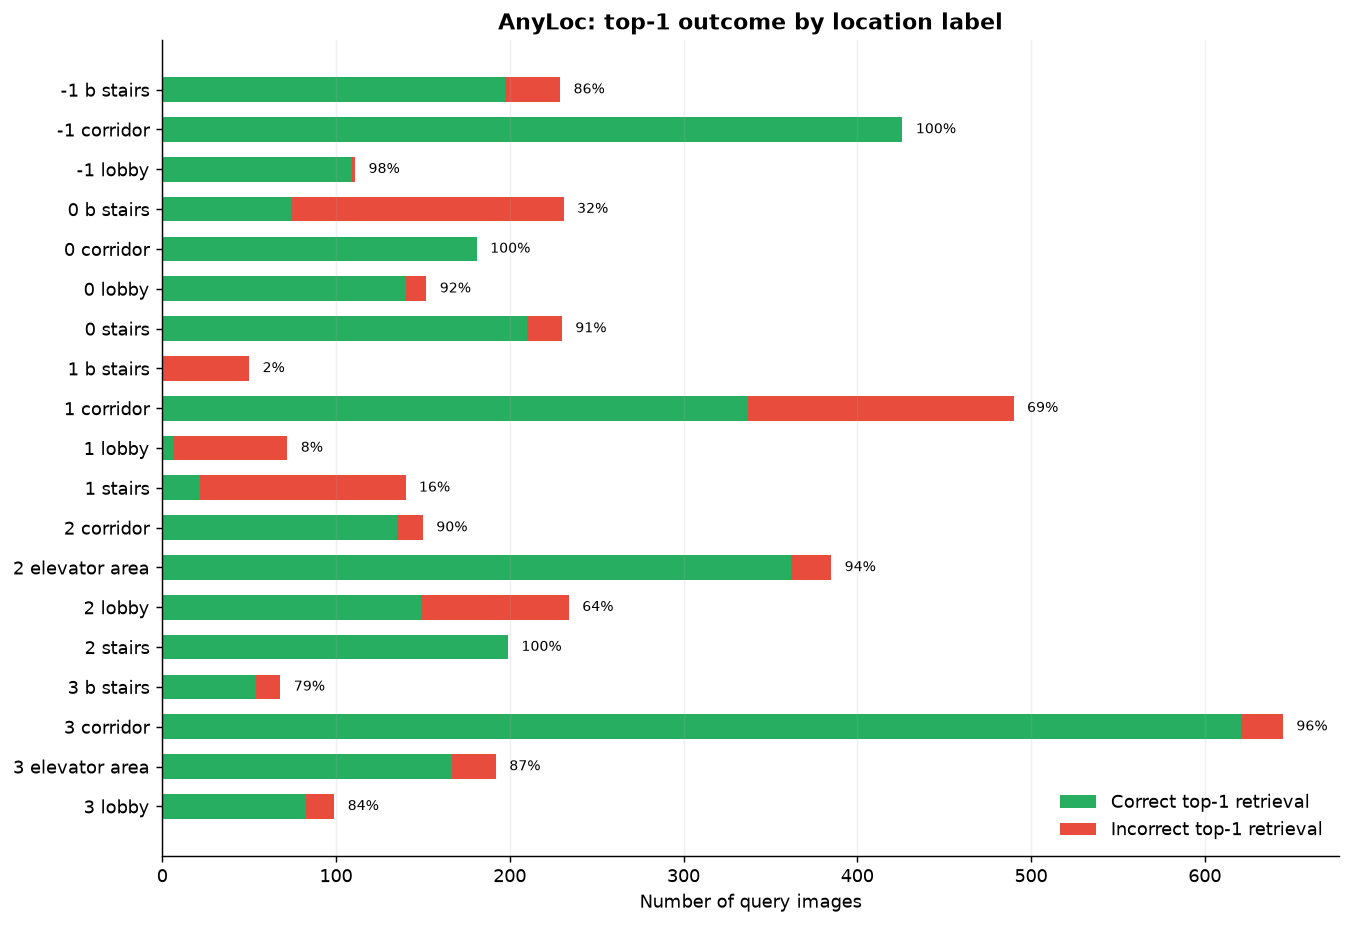

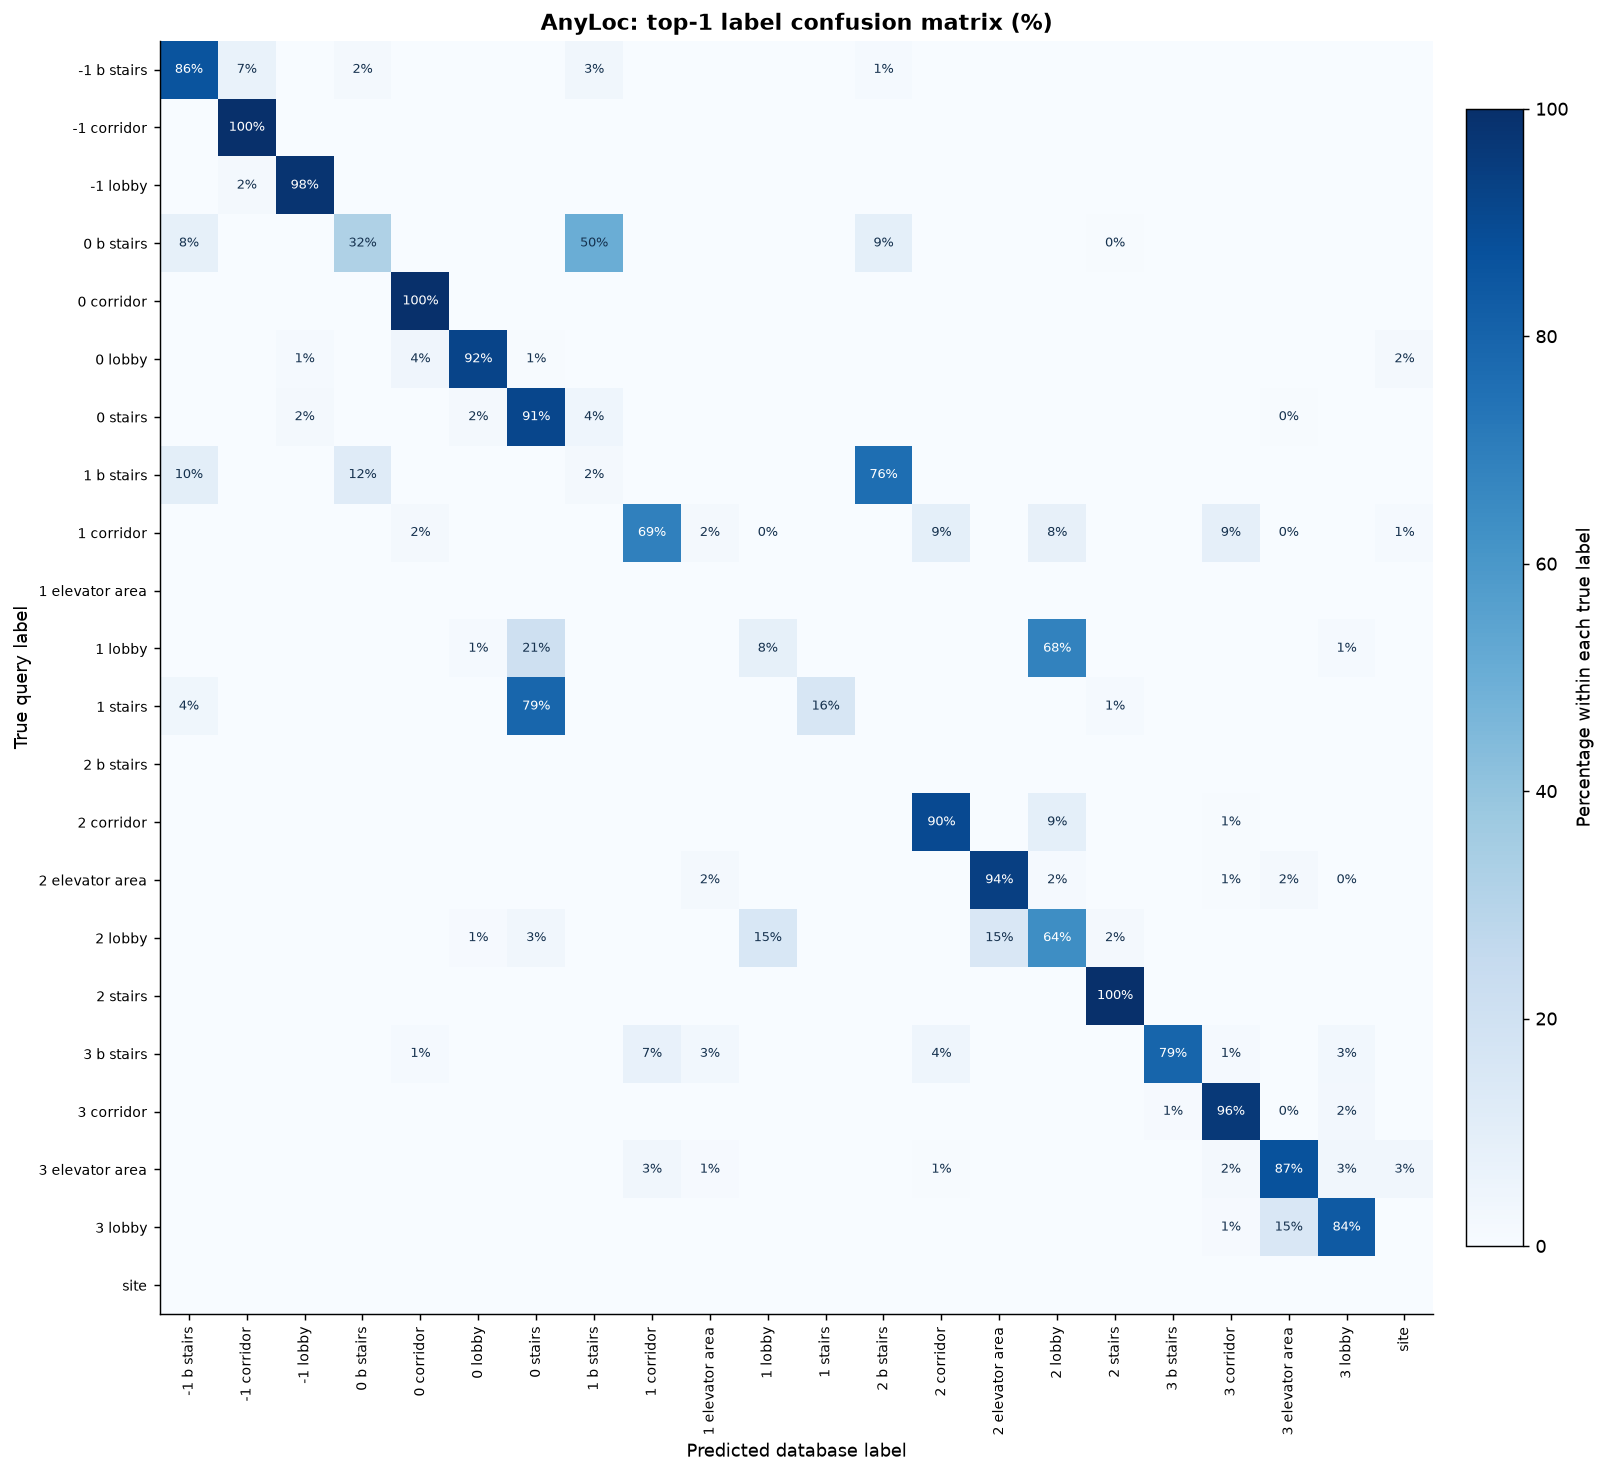

In [10]:
figure,axis=plt.subplots(figsize=(7.5,4.8)); values=[100*recall[k] for k in TOP_K_VALUES]; axis.plot(TOP_K_VALUES,values,color='#2b6cb0',marker='o',linewidth=2.5,markersize=7)
for k,value in zip(TOP_K_VALUES,values): axis.annotate(f'{value:.1f}%',(k,value),xytext=(0,9),textcoords='offset points',ha='center',fontweight='bold')
axis.set(title='AnyLoc on dataset-2',xlabel='Retrieval depth K',ylabel='Recall@K (%)',xticks=TOP_K_VALUES,ylim=(0,102)); axis.grid(axis='y',alpha=.25); figure.tight_layout(); figure.savefig(FIGURE_DIR/'anyloc_recall_at_k.pdf',bbox_inches='tight'); figure.savefig(FIGURE_DIR/'anyloc_recall_at_k.png',bbox_inches='tight',dpi=300); plt.show()

location_labels=sorted(count_by_label); correct=np.array([correct_by_label[label] for label in location_labels]); total=np.array([count_by_label[label] for label in location_labels]); y=np.arange(len(location_labels)); figure,axis=plt.subplots(figsize=(10.5,max(5.5,.38*len(location_labels))))
axis.barh(y,correct,color='#27ae60',height=.62,label='Correct top-1 retrieval'); axis.barh(y,total-correct,left=correct,color='#e74c3c',height=.62,label='Incorrect top-1 retrieval')
for yi,hit,n in zip(y,correct,total): axis.text(n+max(total)*.012,yi,f'{hit/n:.0%}',va='center',fontsize=8)
axis.set(yticks=y,yticklabels=location_labels,xlabel='Number of query images',title='AnyLoc: top-1 outcome by location label'); axis.invert_yaxis(); axis.grid(axis='x',alpha=.18); axis.legend(loc='lower right',frameon=False); figure.tight_layout(); figure.savefig(FIGURE_DIR/'anyloc_label_recall_at_1.pdf',bbox_inches='tight'); plt.show()

matrix_labels=sorted(set(count_by_label)|{predicted for _,predicted in confusions}); index={label:i for i,label in enumerate(matrix_labels)}; matrix=np.zeros((len(matrix_labels),len(matrix_labels)))
for (truth,predicted),count in confusions.items(): matrix[index[truth],index[predicted]]+=count
percentage=np.divide(matrix,matrix.sum(axis=1,keepdims=True),out=np.zeros_like(matrix),where=matrix.sum(axis=1,keepdims=True)>0)*100; size=max(10,.52*len(matrix_labels)); figure,axis=plt.subplots(figsize=(size+2,size)); image=axis.imshow(percentage,cmap='Blues',vmin=0,vmax=100)
for row in range(len(matrix_labels)):
    for column in range(len(matrix_labels)):
        if percentage[row,column]>0: axis.text(column,row,f"{percentage[row,column]:.0f}%",ha='center',va='center',fontsize=7,color='white' if percentage[row,column]>=55 else '#16324f')
axis.set(xticks=range(len(matrix_labels)),xticklabels=matrix_labels,yticks=range(len(matrix_labels)),yticklabels=matrix_labels,xlabel='Predicted database label',ylabel='True query label',title='AnyLoc: top-1 label confusion matrix (%)'); axis.tick_params(axis='x',labelrotation=90,labelsize=8); axis.tick_params(axis='y',labelsize=8); figure.colorbar(image,ax=axis,fraction=.035,pad=.02,label='Percentage within each true label'); figure.tight_layout(); figure.savefig(FIGURE_DIR/'anyloc_top1_confusion_matrix.pdf',bbox_inches='tight'); plt.show()

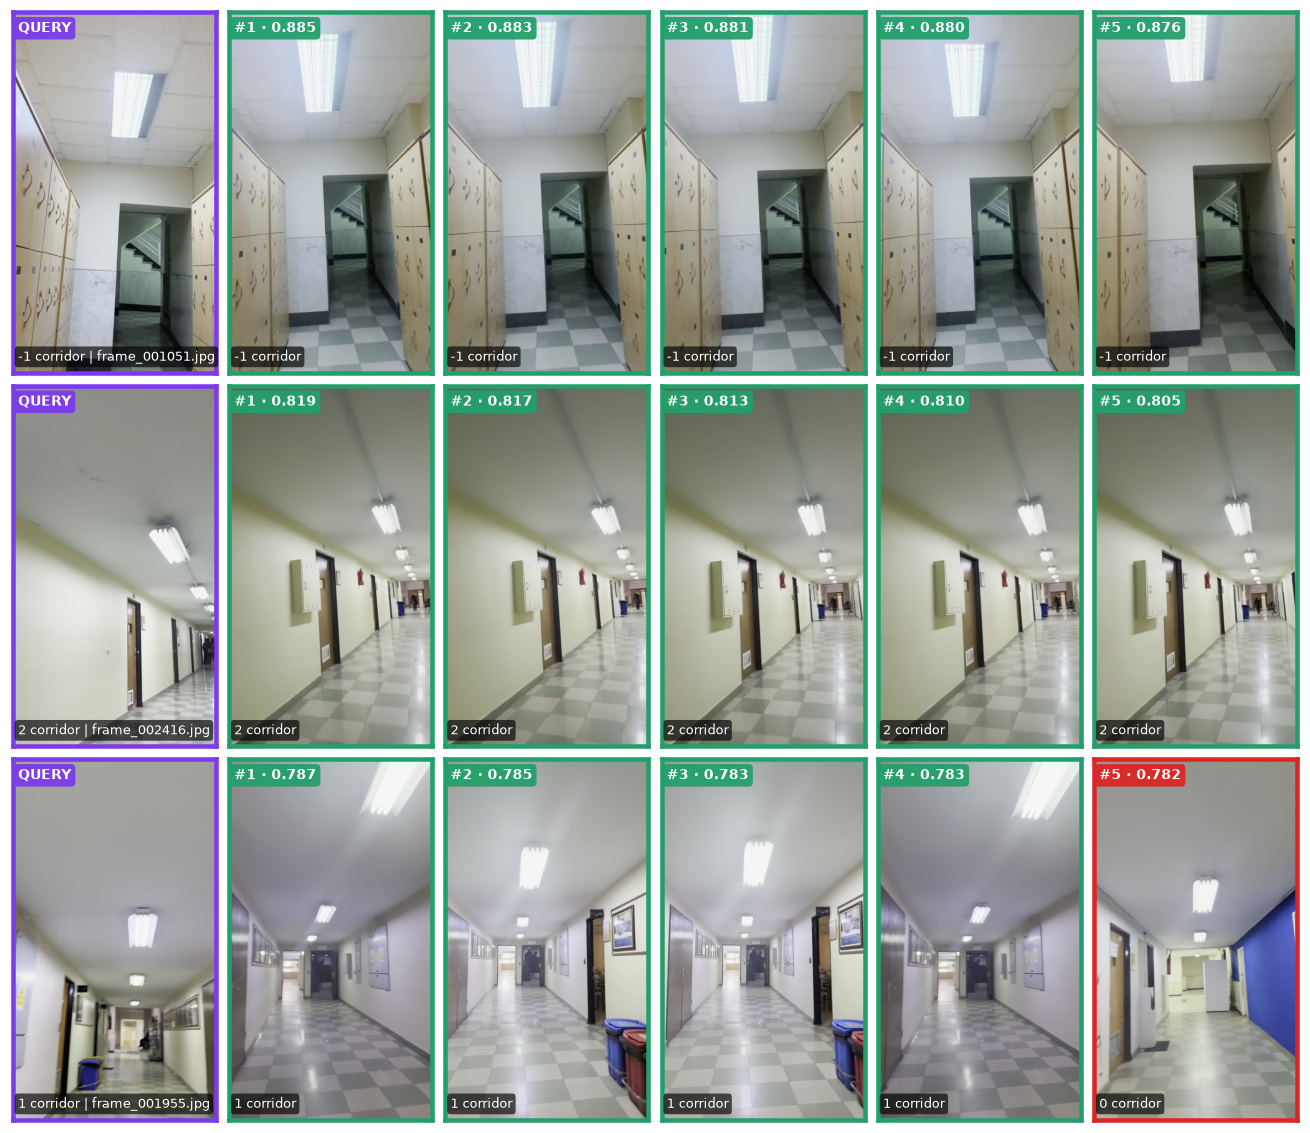

In [35]:
RETRIEVAL_EXAMPLE_INDICES=None  # Set three query indices here to curate the panel.
if RETRIEVAL_EXAMPLE_INDICES is not None:
    lookup={row['query_index']:row for row in examples}; retrieval_examples=[lookup[index] for index in RETRIEVAL_EXAMPLE_INDICES]
retrieval_examples=[all_correct[1000],all_correct[len(all_correct)//2],one_incorrect[50]]
def card(axis,path,header,footer,color):
    with Image.open(path) as image: axis.imshow(image.convert('RGB'))
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values(): spine.set_visible(True); spine.set_linewidth(2.5); spine.set_edgecolor(color)
    axis.text(.025,.975,header,transform=axis.transAxes,ha='left',va='top',color='white',fontsize=8,fontweight='bold',bbox={'boxstyle':'round,pad=.28','facecolor':color,'edgecolor':'none','alpha':.95})
    axis.text(.025,.025,footer,transform=axis.transAxes,ha='left',va='bottom',color='white',fontsize=7.3,bbox={'boxstyle':'round,pad=.25','facecolor':'#000000','edgecolor':'none','alpha':.65})
figure,axes=plt.subplots(3,6,figsize=(10,9),facecolor='white',gridspec_kw={'hspace':.035,'wspace':0})
for row_number,row in enumerate(retrieval_examples):
    card(axes[row_number,0],row['query_path'],'QUERY',f"{row['query_label']} | {row['query_path'].name}",'#7C3AED')
    for rank,(database_index,score,is_correct) in enumerate(zip(row['top5_indices'],row['top5_scores'],row['top5_correct']),start=1):
        path=database_paths[int(database_index)]; card(axes[row_number,rank],path,f'#{rank} · {score:.3f}',database_label_by_name[path.name],'#22a06b' if is_correct else '#dc2626')
figure.subplots_adjust(left=.001,right=.999,bottom=.008,top=.955,hspace=.035,wspace=0); figure.savefig(FIGURE_DIR/'anyloc_top5_retrieval_examples.pdf',bbox_inches='tight',facecolor='white'); figure.savefig(FIGURE_DIR/'anyloc_top5_retrieval_examples.png',bbox_inches='tight',dpi=300,facecolor='white'); plt.show()

## 2. DINOv2 layer and facet similarity maps

Each heatmap shows, for every query patch, the maximum cosine similarity to any reference-image patch. Choose a matched reference/query pair and the layers to compare. All facets share the same colour scale.

Using cache found in /Users/armin/.cache/torch/hub/facebookresearch_dinov2_main


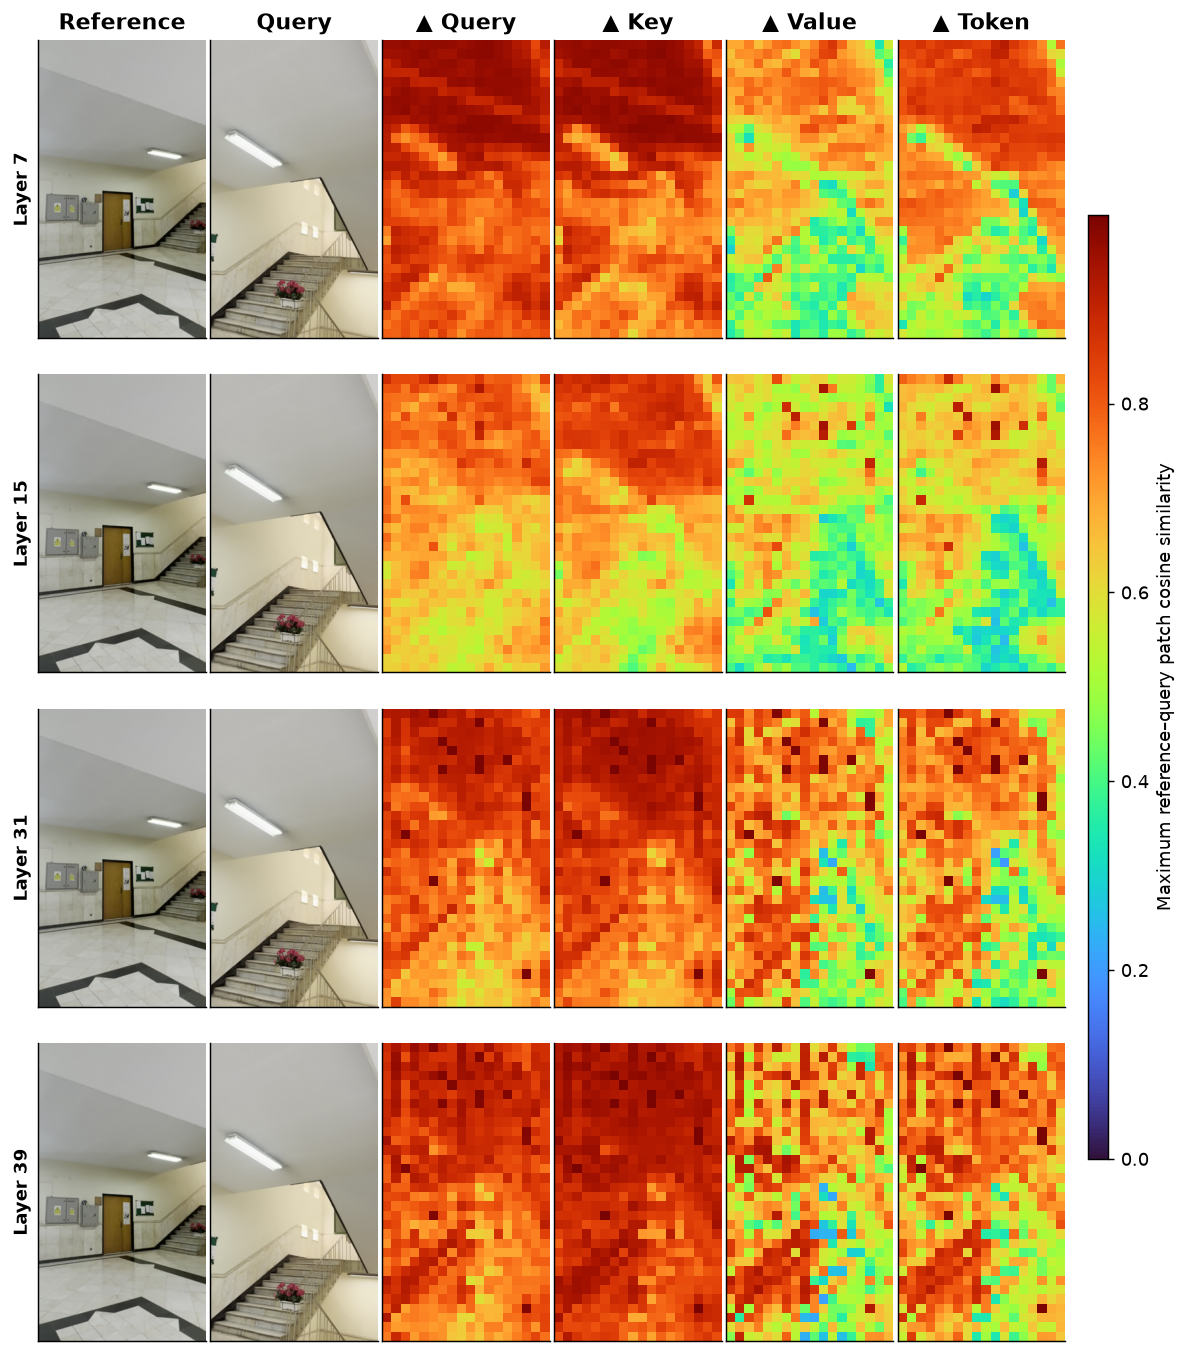

In [28]:
import gc

import indoor_vpr.algorithms.anyloc.algorithm as anyloc_module
importlib.reload(anyloc_module)

# A ViT-G model at full camera resolution needs tens of GiB on MPS. 448 px
# retains a useful patch map (up to 32 x 32 patches) while fitting safely.
DINO_MODEL = 'dinov2_vitg14'
DINO_MAP_MAX_IMAGE_SIZE = 448  # Lower to 392 if memory remains constrained.
DINO_LAYERS = [7, 15, 31, 39]
DINO_FACETS = ['query', 'key', 'value', 'token']
# DINO_QUERY_INDEX = retrieval_examples[0]['query_index']
DINO_QUERY_INDEX = 281
# DINO_QUERY_INDEX = 630

# DINO_DATABASE_INDEX = int(retrieval_examples[0]['top5_indices'][0])  # Adjust these two indices.
DINO_DATABASE_INDEX = 813
# DINO_DATABASE_INDEX = 1175

# One model is kept in memory. Unlike the previous version, no model is
# created per layer/facet, and each pair needs only two forward passes.
if 'extractor' in globals():
    extractor.close()
    del extractor
gc.collect()
base = anyloc_module.AnyLoc(model_name=DINO_MODEL, layer=31, facet='value', num_clusters=32, max_image_size=DINO_MAP_MAX_IMAGE_SIZE)
torch = base.torch
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

def dino_tensor(path):
    with Image.open(path) as image:
        tensor = base.to_tensor(image.convert('RGB'))  # Resize on CPU before moving to MPS.
    height, width = tensor.shape[-2:]
    scale = min(1.0, DINO_MAP_MAX_IMAGE_SIZE / max(height, width))
    if scale < 1:
        tensor = base.resize(tensor, [round(height * scale), round(width * scale)], interpolation=base.interpolation_mode.BICUBIC, antialias=True)
    height, width = tensor.shape[-2:]
    tensor = base.center_crop(tensor, [(height // 14) * 14, (width // 14) * 14])
    mean = torch.tensor([.485, .456, .406])[:, None, None]
    std = torch.tensor([.229, .224, .225])[:, None, None]
    rgb = (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    return tensor.to(base.device), rgb

reference_tensor, reference_rgb = dino_tensor(database_paths[DINO_DATABASE_INDEX])
query_tensor, query_rgb = dino_tensor(query_paths[DINO_QUERY_INDEX])
model = base.extractor.model
blocks = model.blocks
prefix_tokens = 1 + getattr(model, 'num_register_tokens', 0)

def layer_features(tensor, layer):
    captured = {}
    def save(name):
        def hook(_module, _inputs, output):
            captured[name] = output.detach().float().cpu()
        return hook
    block = blocks[layer]
    handles = [block.register_forward_hook(save('token')), block.attn.qkv.register_forward_hook(save('qkv'))]
    try:
        with torch.inference_mode():
            model(tensor.unsqueeze(0))
    finally:
        for handle in handles:
            handle.remove()
    base.extractor.output = None  # Release the adapter's regular hook output.
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    return captured

def facet_tokens(captured, facet):
    if facet == 'token':
        features = captured['token'][:, prefix_tokens:, :]
    else:
        qkv = captured['qkv'][:, prefix_tokens:, :]
        width = qkv.shape[-1] // 3
        index = {'query': 0, 'key': 1, 'value': 2}[facet]
        features = qkv[..., index * width:(index + 1) * width]
    return torch.nn.functional.normalize(features.squeeze(0), dim=-1)

maps, maximum = {}, 0
for layer in DINO_LAYERS:
    reference_features = layer_features(reference_tensor, layer)
    query_features = layer_features(query_tensor, layer)
    for facet in DINO_FACETS:
        reference = facet_tokens(reference_features, facet)
        query = facet_tokens(query_features, facet)
        similarity = (query @ reference.T).max(dim=1).values.numpy().reshape(query_tensor.shape[-2] // 14, query_tensor.shape[-1] // 14)
        maps[(layer, facet)] = similarity
        maximum = max(maximum, similarity.max())

# Match the portrait image aspect ratio, so every column is compact and evenly spaced.
figure, axes = plt.subplots(len(DINO_LAYERS), 2 + len(DINO_FACETS), figsize=(8.7, 11), gridspec_kw={'wspace': .025, 'hspace': 0.0})
for row, layer in enumerate(DINO_LAYERS):
    axes[row, 0].imshow(reference_rgb); axes[row, 1].imshow(query_rgb)
    for column, facet in enumerate(DINO_FACETS, start=2):
        image = axes[row, column].imshow(maps[(layer, facet)], cmap='turbo', vmin=0, vmax=maximum, interpolation='nearest')
    for axis in axes[row]:
        axis.set_xticks([]); axis.set_yticks([])
    axes[row, 0].set_ylabel(f'Layer {layer}', fontweight='bold')
for axis, title in zip(axes[0], ['Reference', 'Query', *['▲ ' + facet.title() for facet in DINO_FACETS]]):
    axis.set_title(title, fontweight='bold')
# A dedicated colourbar axis avoids Matplotlib compressing only the heatmap columns.
figure.subplots_adjust(left=.012, right=.92, bottom=.02, top=.955, wspace=.025)
colorbar_axis = figure.add_axes([.94, .16, .018, .66])
figure.colorbar(image, cax=colorbar_axis, label='Maximum reference–query patch cosine similarity')
# figure.suptitle('AnyLoc: DINOv2 ViT-G layer and facet similarity maps', y=.995, fontsize=15, fontweight='bold')
figure.savefig(FIGURE_DIR / 'anyloc_dinov2_layer_facet_maps.pdf', bbox_inches='tight')
figure.savefig(FIGURE_DIR / 'anyloc_dinov2_layer_facet_maps.png', bbox_inches='tight', dpi=300)
plt.show()

## 4. AnyLoc occlusion sensitivity

The upper row is the exact DINOv2 input. The lower row is a standalone heatmap: dark blue denotes a small descriptor change and dark red a large change.

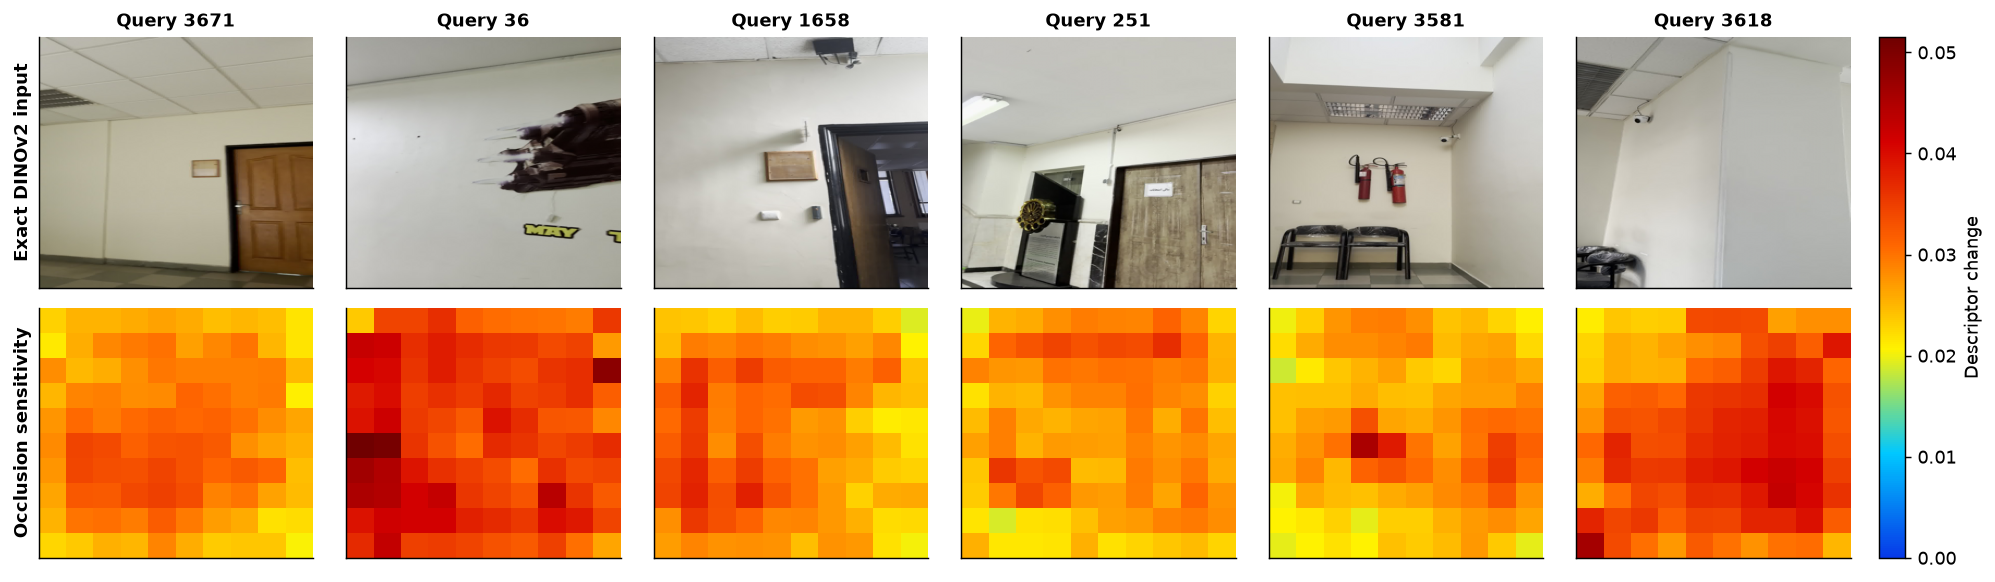

In [36]:
from matplotlib.colors import LinearSegmentedColormap

OCCLUSION_QUERY_INDICES = [3671, 36, 1658, 251, 3581, 3618]; OCCLUSION_GRID=10; OCCLUDER_FRACTION=.22
def prepared_dino(path):
    with Image.open(path) as source: tensor=base.to_tensor(source.convert('RGB')).to(base.device)
    height,width=tensor.shape[-2:]; scale=min(1.0,base.max_image_size/max(height,width))
    if scale<1: tensor=base.resize(tensor,[round(height*scale),round(width*scale)],interpolation=base.interpolation_mode.BICUBIC,antialias=True)
    height,width=tensor.shape[-2:]; tensor=base.center_crop(tensor,[(height//14)*14,(width//14)*14]); mean=base.torch.tensor([.485,.456,.406])[:,None,None]; std=base.torch.tensor([.229,.224,.225])[:,None,None]
    return tensor,(tensor.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()
def dino_descriptor(tensor): return base.extractor(tensor.unsqueeze(0)).squeeze(0).mean(dim=0).detach().cpu().numpy()
def occlusion_map(path):
    tensor,rgb=prepared_dino(path); height,width=tensor.shape[-2:]; patch=max(16,round(min(width,height)*OCCLUDER_FRACTION)); baseline=dino_descriptor(tensor); gray=base.torch.tensor([(0.5-.485)/.229,(0.5-.456)/.224,(0.5-.406)/.225],device=base.device)[:,None,None]; heatmap=np.zeros((OCCLUSION_GRID,OCCLUSION_GRID))
    for row in range(OCCLUSION_GRID):
        for column in range(OCCLUSION_GRID):
            x=round(column*(width-patch)/max(1,OCCLUSION_GRID-1)); y=round(row*(height-patch)/max(1,OCCLUSION_GRID-1)); occluded=tensor.clone(); occluded[:,y:y+patch,x:x+patch]=gray; heatmap[row,column]=np.linalg.norm(baseline-dino_descriptor(occluded))
    return rgb,heatmap
results=[occlusion_map(query_paths[index]) for index in OCCLUSION_QUERY_INDICES]; maximum=max(heatmap.max() for _,heatmap in results); cmap=LinearSegmentedColormap.from_list('sensitivity',['#0739e8','#00c8ff','#fff200','#ff6700','#d40000','#700000'])
figure,axes=plt.subplots(2,len(results),figsize=(3.1*len(results),5.2),gridspec_kw={'hspace':.08,'wspace':.12})
for column,(rgb,heatmap) in enumerate(results):
    height,width=rgb.shape[:2]; axes[0,column].imshow(rgb,aspect='auto'); axes[0,column].set_title(f'Query {OCCLUSION_QUERY_INDICES[column]}',fontsize=10); heatmap_image=axes[1,column].imshow(heatmap,cmap=cmap,vmin=0,vmax=maximum,interpolation='nearest',extent=(0,width,height,0),aspect='auto')
    for axis in axes[:,column]: axis.set_xticks([]); axis.set_yticks([]); axis.set_aspect('auto')
axes[0,0].set_ylabel('Exact DINOv2 input',fontweight='bold'); axes[1,0].set_ylabel('Occlusion sensitivity',fontweight='bold'); figure.colorbar(heatmap_image,ax=axes.ravel().tolist(),fraction=.018,pad=.015,label='Descriptor change'); figure.savefig(FIGURE_DIR/'anyloc_occlusion_sensitivity.pdf',bbox_inches='tight'); figure.savefig(FIGURE_DIR/'anyloc_occlusion_sensitivity.png',bbox_inches='tight',dpi=300); plt.show()